In [2]:
import pandas as pd

df = pd.read_csv('ESS11e04_1.csv', usecols=[
    'vote', 'trstprl', 'trstplt', 'trstprt', 'trstlgl',
    'polintr', 'cptppola', 'psppsgva', 'psppipla', 'lrscale',
    'stfdem', 'stfgov', 'stfeco', 'nwspol', 'netusoft',
    'contplt', 'sgnptit', 'clsprty',
    'eisced', 'hinctnta', 'gndr', 'agea', 'cntry',
    'pspwght', 'anweight'
])

# Remove "not eligible to vote" (vote == 3)
df = df[df['vote'] != 3]
print(df['vote'].value_counts())  # 1=Yes, 2=No

vote
1    36293
2    10177
8      246
7      227
9       22
Name: count, dtype: int64


In [3]:
df['voted'] = (df['vote'] == 1).astype(int)
print(df['voted'].value_counts(normalize=True).round(3))
# Expect: 1 → ~0.75,  0 → ~0.25

voted
1    0.773
0    0.227
Name: proportion, dtype: float64


<Axes: title={'center': 'trstprt'}>

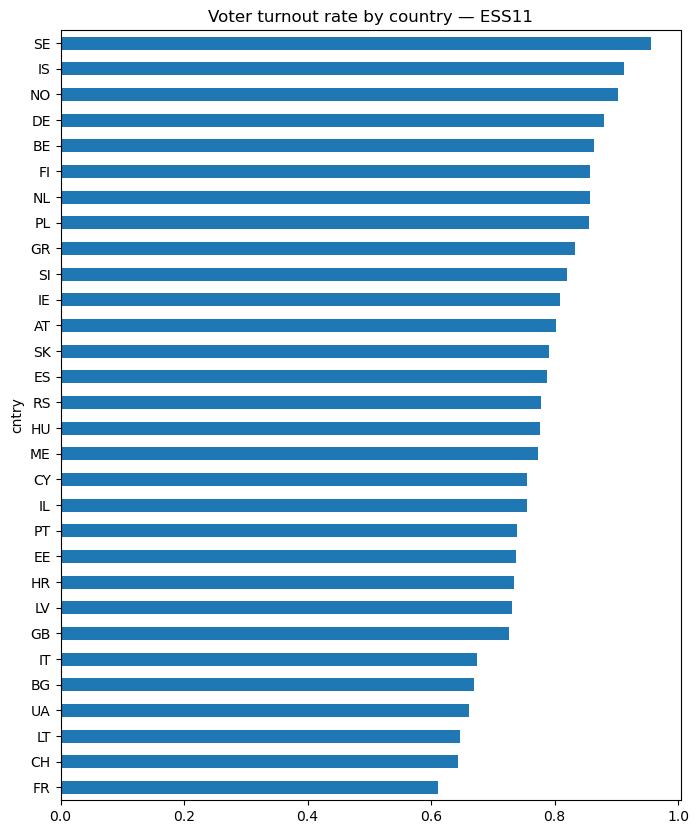

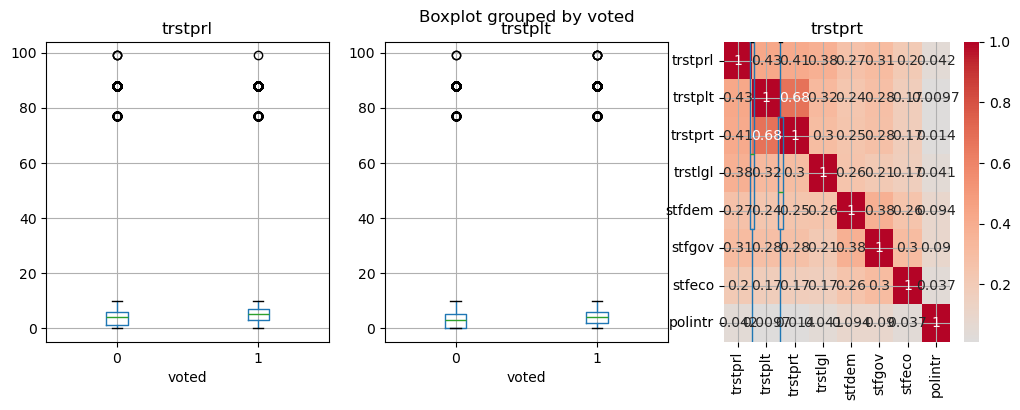

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Turnout by country
turnout_by_country = df.groupby('cntry')['voted'].mean().sort_values()
turnout_by_country.plot(kind='barh', figsize=(8,10))
plt.title('Voter turnout rate by country — ESS11')

# Trust distributions: voters vs non-voters
trust_vars = ['trstprl', 'trstplt', 'trstprt']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, var in zip(axes, trust_vars):
    df.boxplot(column=var, by='voted', ax=ax)

# Correlation heatmap
corr_vars = ['trstprl','trstplt','trstprt','trstlgl','stfdem','stfgov','stfeco','polintr']
sns.heatmap(df[corr_vars].corr(), annot=True, cmap='coolwarm', center=0)

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Recode ESS missing codes (77, 88, 99) as NaN
ess_missing = [66, 77, 88, 99, 999]
df.replace(ess_missing, np.nan, inplace=True)

# Add missingness indicator for lrscale
df['lrscale_missing'] = df['lrscale'].isna().astype(int)

# Median impute ordinal vars
imputer = SimpleImputer(strategy='median')
feature_cols = ['trstprl','trstplt','trstprt','trstlgl',
                'polintr','cptppola','psppsgva','lrscale',
                'stfdem','stfgov','stfeco',
                'nwspol','netusoft',
                'eisced','hinctnta','gndr','agea',
                'lrscale_missing']
df[feature_cols] = imputer.fit_transform(df[feature_cols])

# One-hot encode country (fixed effects)
df = pd.get_dummies(df, columns=['cntry'], drop_first=True)

# Standard scale continuous features
scaler = StandardScaler()
scale_cols = ['trstprl','trstplt','trstprt','trstlgl',
              'stfdem','stfgov','stfeco','nwspol','netustm',
              'agea','hinctnta']
df[scale_cols] = scaler.fit_transform(df[scale_cols])


KeyError: "None of [Index(['cntry'], dtype='object')] are in the [columns]"